# EEG Denoising with Empirical Mode Decomposition (EMD)

**Dataset:** EEGDenoiseNet — 7 artifact combos × 3 splits (train / val / test)  
**Method:** EMD → IMF thresholding → signal reconstruction  
**Metrics:** MSE · RMSE · RRMSE · SNR (dB) · Spectral Loss

---

### Pipeline
```
noisy EEG ──► EMD decompose ──► classify IMFs (artifact vs signal)
          ──► zero / soft-threshold artifact IMFs ──► reconstruct ──► evaluate
```

### Dataset layout
```
{combo}_{split}.h5
  /clean  float32 (N, 512)   ground-truth EEG
  /noisy  float32 (N, 512)   contaminated EEG
```
Combos: `emg`, `eog`, `ecg`, `emg_eog`, `emg_ecg`, `eog_ecg`, `emg_eog_ecg`  
Each combo: 45 140 rows — 80 % train / 10 % val / 10 % test

## 1 · Install & Imports

In [21]:
# PyEMD is not pre-installed on Kaggle kernels
!pip install EMD-signal --quiet

In [22]:
import os
import gc
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import h5py
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal as scipy_signal
from PyEMD import EMD
from tqdm.notebook import tqdm

print('All imports OK')

All imports OK


## 2 · Configuration

In [23]:
# ── Dataset ──────────────────────────────────────────────────────────────────
# Point this to wherever your .h5 files live on Kaggle
DATA_DIR = '/kaggle/input/datasets/lucky3663/eegdenoise'   # <── update if needed

COMBOS = ['emg', 'eog', 'ecg', 'emg_eog', 'emg_ecg', 'eog_ecg', 'emg_eog_ecg']
SPLITS  = ['train', 'val', 'test']

FS   = 256    # sampling frequency (Hz)
NSEG = 512    # samples per segment (2 s @ 256 Hz)

# ── EMD hyper-parameters ─────────────────────────────────────────────────────
MAX_IMFS       = 8      # maximum IMFs to extract per segment
THRESHOLD_MODE = 'soft' # 'hard' | 'soft' — how artifact IMFs are suppressed

# IMF selection strategy
#   'energy' → suppress IMFs whose energy ratio > ENERGY_THRESH
#   'index'  → suppress the first N_ARTIFACT_IMFS (highest-frequency) IMFs
IMF_SELECT_STRATEGY = 'energy'
ENERGY_THRESH       = 0.40   # energy fraction above which an IMF is artifact
N_ARTIFACT_IMFS     = 2      # used only when strategy = 'index'

# ── Evaluation ────────────────────────────────────────────────────────────────
EVAL_SPLIT  = 'test'    # split used for final metric reporting
MAX_SAMPLES = None      # cap per combo to keep runtime sane; set None for full

# ── Output ───────────────────────────────────────────────────────────────────
RESULTS_CSV = '/kaggle/working/emd_results.csv'
FIGS_DIR    = '/kaggle/working/figures'
os.makedirs(FIGS_DIR, exist_ok=True)

print(f'Config OK — DATA_DIR: {DATA_DIR}')

Config OK — DATA_DIR: /kaggle/input/datasets/lucky3663/eegdenoise


## 3 · Helper Functions

In [24]:
# ─────────────────────────────────────────────────────────────────────────────
#  DATA LOADER
# ─────────────────────────────────────────────────────────────────────────────

def load_h5(combo: str, split: str, max_samples=None):
    """Load clean / noisy arrays from {combo}_{split}.h5"""
    path = os.path.join(DATA_DIR, f'{combo}_{split}.h5')
    if not os.path.exists(path):
        raise FileNotFoundError(f'Not found: {path}')
    with h5py.File(path, 'r') as f:
        clean = f['clean'][:max_samples].astype(np.float32)
        noisy = f['noisy'][:max_samples].astype(np.float32)
    return clean, noisy


# ─────────────────────────────────────────────────────────────────────────────
#  METRICS  (all operate on flat 1-D arrays; batch wrappers average over N)
# ─────────────────────────────────────────────────────────────────────────────

def mse_fn(clean, est):
    """Mean Squared Error"""
    return float(np.mean((clean - est) ** 2))

def rmse_fn(clean, est):
    """Root Mean Squared Error"""
    return float(np.sqrt(mse_fn(clean, est)))

def rrmse_fn(clean, est):
    """Relative RMSE  =  RMSE / RMS(clean)"""
    rms_c = float(np.sqrt(np.mean(clean ** 2)))
    return rmse_fn(clean, est) / (rms_c + 1e-12)

def snr_db_fn(clean, est):
    """Signal-to-Noise Ratio in dB"""
    sig_pwr   = float(np.mean(clean ** 2))
    noise_pwr = float(np.mean((clean - est) ** 2))
    return 10.0 * np.log10(sig_pwr / (noise_pwr + 1e-12))

def spectral_loss_fn(clean, est, fs=FS):
    """Mean absolute log-spectral distance over 0.5–45 Hz"""
    nperseg = min(256, len(clean))
    f, Pc = scipy_signal.welch(clean, fs=fs, nperseg=nperseg)
    _, Pd = scipy_signal.welch(est,   fs=fs, nperseg=nperseg)
    mask  = (f >= 0.5) & (f <= 45.0)
    return float(np.mean(np.abs(
        10 * np.log10(Pc[mask] + 1e-12) -
        10 * np.log10(Pd[mask] + 1e-12)
    )))


def compute_metrics_batch(clean_batch, est_batch, fs=FS):
    """
    Compute all metrics over a batch (N, T) — returns mean over samples.
    """
    mse_v, rmse_v, rrmse_v, snr_v, spec_v = [], [], [], [], []
    for c, d in zip(clean_batch, est_batch):
        mse_v.append(mse_fn(c, d))
        rmse_v.append(rmse_fn(c, d))
        rrmse_v.append(rrmse_fn(c, d))
        snr_v.append(snr_db_fn(c, d))
        spec_v.append(spectral_loss_fn(c, d, fs))
    return {
        'MSE':           float(np.mean(mse_v)),
        'RMSE':          float(np.mean(rmse_v)),
        'RRMSE':         float(np.mean(rrmse_v)),
        'SNR_dB':        float(np.mean(snr_v)),
        'Spectral_Loss': float(np.mean(spec_v)),
    }


print('Metric helpers defined.')

Metric helpers defined.


In [25]:
# ─────────────────────────────────────────────────────────────────────────────
#  EMD DENOISING
# ─────────────────────────────────────────────────────────────────────────────

emd_engine = EMD()
emd_engine.MAX_ITERATION = 200


def _soft_threshold(x: np.ndarray, thr: float) -> np.ndarray:
    return np.sign(x) * np.maximum(np.abs(x) - thr, 0.0)


def emd_denoise_single(
    noisy: np.ndarray,
    max_imfs: int        = MAX_IMFS,
    strategy: str        = IMF_SELECT_STRATEGY,
    energy_thresh: float = ENERGY_THRESH,
    n_artifact: int      = N_ARTIFACT_IMFS,
    mode: str            = THRESHOLD_MODE,
) -> np.ndarray:
    """
    Denoise a single 1-D EEG segment with EMD.

    Steps
    -----
    1. Decompose the noisy signal into N IMFs via sifting.
    2. Identify artifact IMFs by energy ratio ('energy') or position ('index').
    3. Hard-zero or soft-threshold those IMFs.
    4. Sum surviving IMFs + residue → denoised estimate.
    """
    try:
        imfs = emd_engine.emd(noisy.astype(np.float64), max_imf=max_imfs)
    except Exception:
        return noisy.copy()            # graceful fallback

    if imfs.ndim == 1:
        imfs = imfs[np.newaxis, :]

    n_imfs       = imfs.shape[0]
    energies     = np.sum(imfs ** 2, axis=1)         # (n_imfs,)
    total_e      = energies.sum() + 1e-12
    energy_ratio = energies / total_e

    denoised_imfs = imfs.copy()

    if strategy == 'energy':
        for k in range(n_imfs):
            if energy_ratio[k] > energy_thresh:
                if mode == 'hard':
                    denoised_imfs[k] = 0.0
                else:  # soft
                    thr = energy_thresh * np.std(imfs[k])
                    denoised_imfs[k] = _soft_threshold(imfs[k], thr)

    elif strategy == 'index':
        # IMF-1 = highest frequency, most likely artifact
        for k in range(min(n_artifact, n_imfs)):
            if mode == 'hard':
                denoised_imfs[k] = 0.0
            else:
                thr = np.std(imfs[k])
                denoised_imfs[k] = _soft_threshold(imfs[k], thr)
    else:
        raise ValueError(f'Unknown strategy: {strategy}')

    return denoised_imfs.sum(axis=0).astype(np.float32)


def emd_denoise_batch(
    noisy_batch: np.ndarray,
    desc: str = 'EMD',
    **kwargs,
) -> np.ndarray:
    """Vectorised (loop) wrapper with progress bar."""
    n = noisy_batch.shape[0]
    denoised = np.zeros_like(noisy_batch)
    for i in tqdm(range(n), desc=desc, unit='seg', leave=True):
        denoised[i] = emd_denoise_single(noisy_batch[i], **kwargs)
    return denoised


print('EMD denoising functions defined.')

EMD denoising functions defined.


## 4 · Sanity Check — One Segment

Single-segment metrics: {'MSE': '0.9537', 'RMSE': '0.9766', 'RRMSE': '5.0119', 'SNR_dB': '-14.0000', 'Spec': '11.2879'}


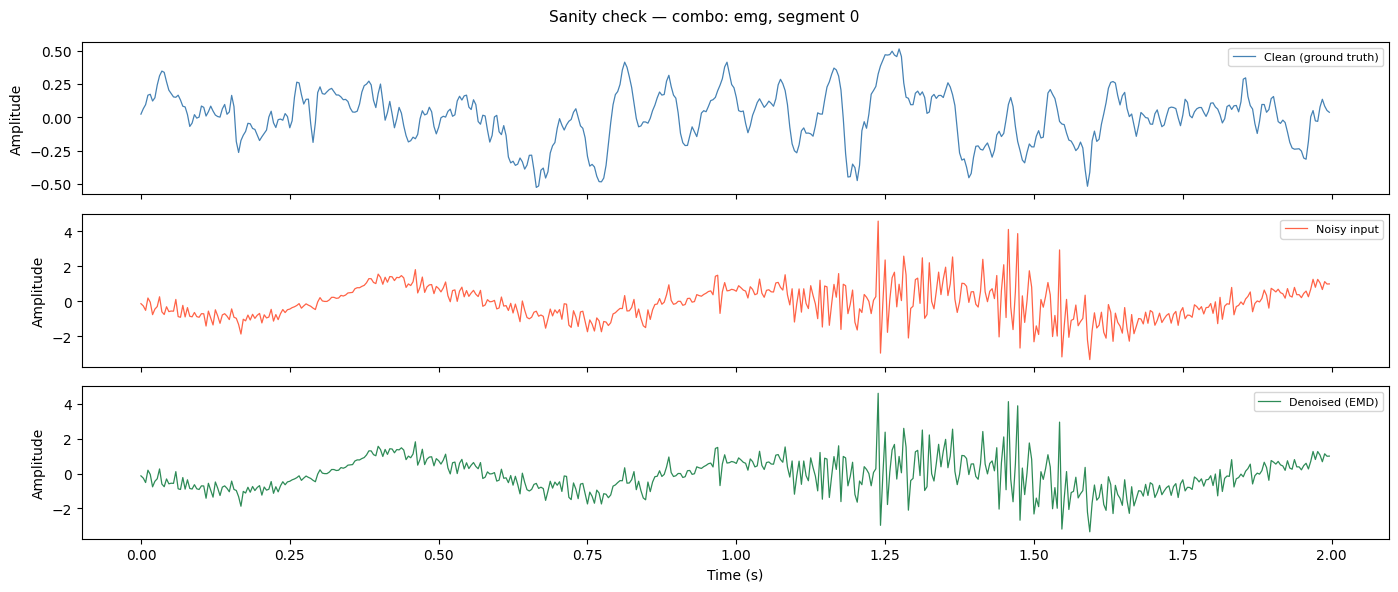

In [26]:
combo_test = COMBOS[0]   # 'emg'
clean_ex, noisy_ex = load_h5(combo_test, 'test', max_samples=5)

t_arr      = np.arange(NSEG) / FS
denoised_0 = emd_denoise_single(noisy_ex[0])

quick_m = {
    'MSE':    mse_fn(clean_ex[0], denoised_0),
    'RMSE':   rmse_fn(clean_ex[0], denoised_0),
    'RRMSE':  rrmse_fn(clean_ex[0], denoised_0),
    'SNR_dB': snr_db_fn(clean_ex[0], denoised_0),
    'Spec':   spectral_loss_fn(clean_ex[0], denoised_0),
}
print('Single-segment metrics:', {k: f'{v:.4f}' for k, v in quick_m.items()})

fig, axes = plt.subplots(3, 1, figsize=(14, 6), sharex=True)
axes[0].plot(t_arr, clean_ex[0],  color='steelblue', lw=0.9, label='Clean (ground truth)')
axes[1].plot(t_arr, noisy_ex[0],  color='tomato',    lw=0.9, label='Noisy input')
axes[2].plot(t_arr, denoised_0,   color='seagreen',  lw=0.9, label='Denoised (EMD)')
for ax in axes:
    ax.legend(loc='upper right', fontsize=8)
    ax.set_ylabel('Amplitude')
axes[2].set_xlabel('Time (s)')
fig.suptitle(f'Sanity check — combo: {combo_test}, segment 0', fontsize=11)
plt.tight_layout()
plt.savefig(f'{FIGS_DIR}/sanity_{combo_test}.png', dpi=150)
plt.show()

## 5 · IMF Decomposition Visualisation

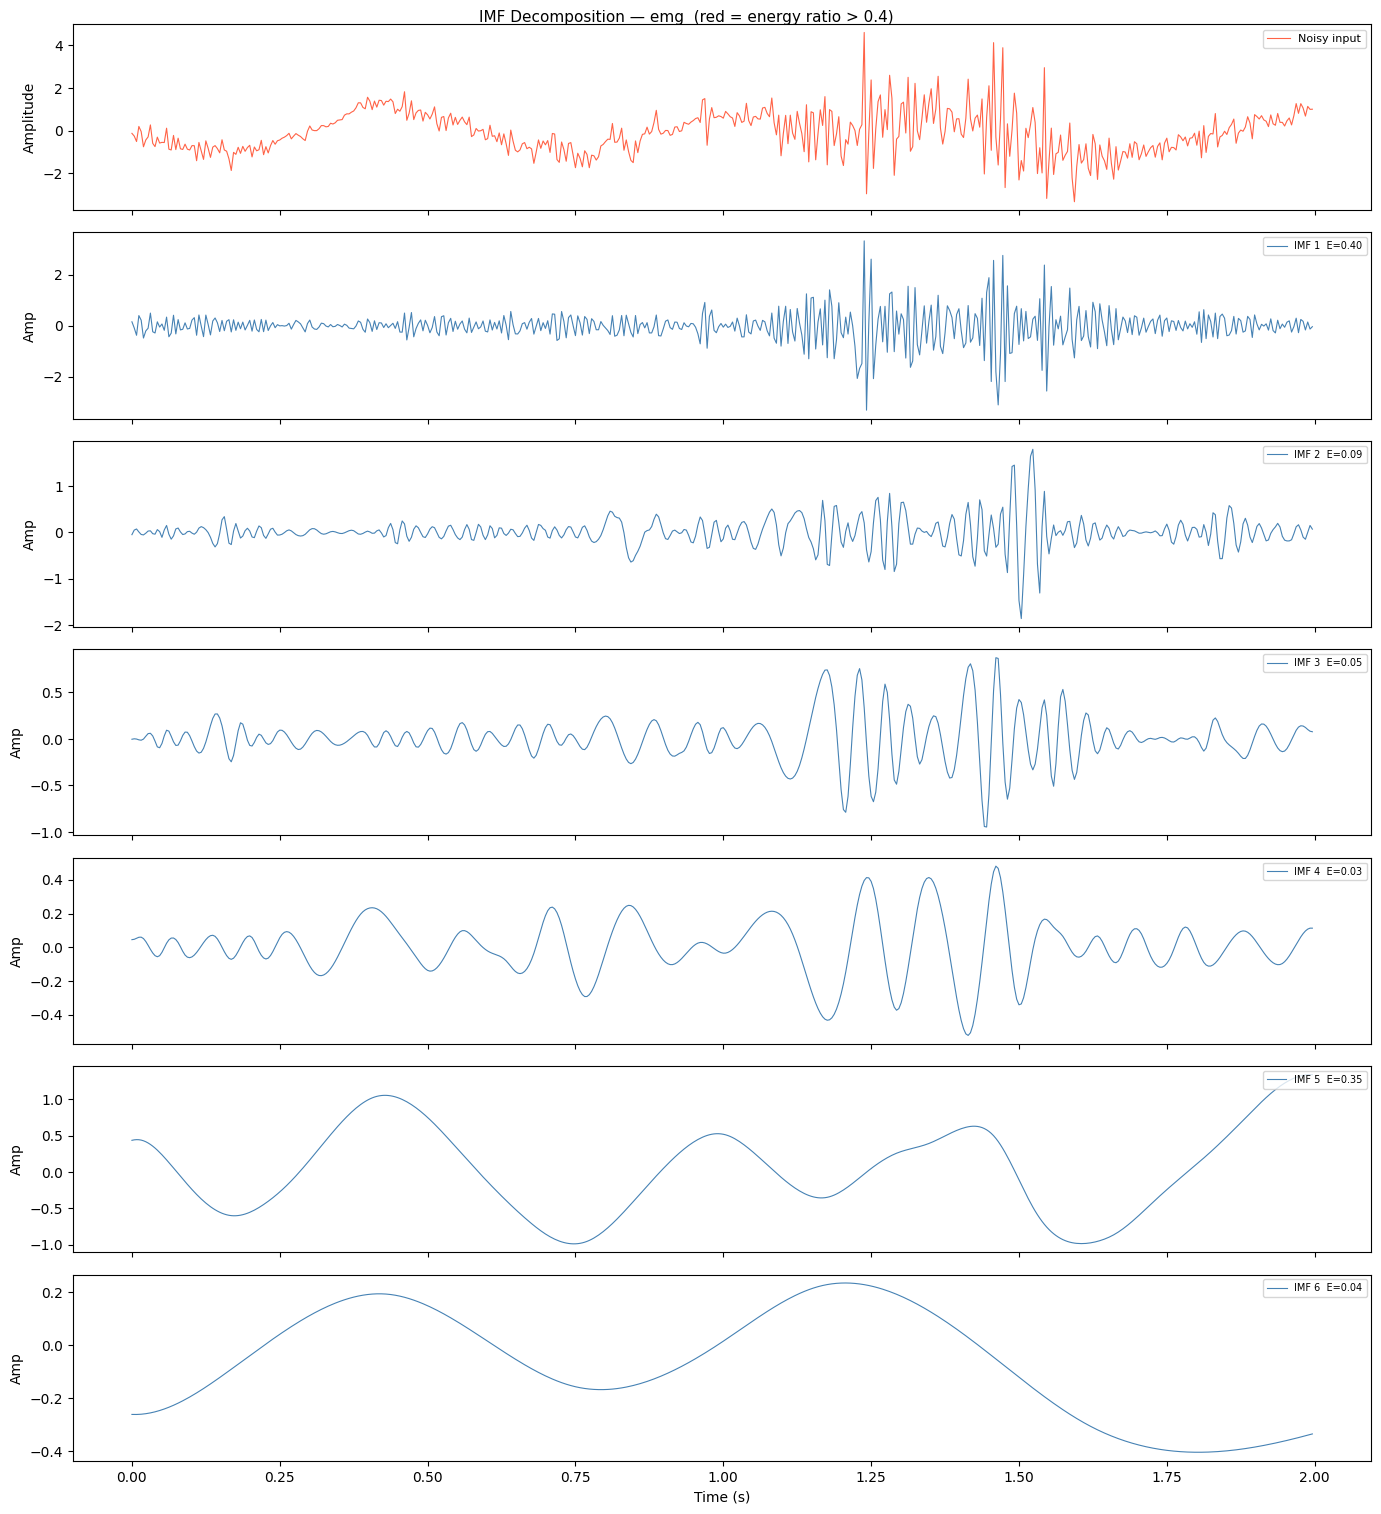

In [27]:
seg_demo = noisy_ex[0].astype(np.float64)
imfs_demo = emd_engine.emd(seg_demo, max_imf=MAX_IMFS)
if imfs_demo.ndim == 1:
    imfs_demo = imfs_demo[np.newaxis, :]

n_show       = min(6, imfs_demo.shape[0])
e_demo       = np.sum(imfs_demo ** 2, axis=1)
e_ratio_demo = e_demo / (e_demo.sum() + 1e-12)

fig, axes = plt.subplots(n_show + 1, 1,
                         figsize=(14, 2.2 * (n_show + 1)), sharex=True)

axes[0].plot(t_arr, seg_demo, color='tomato', lw=0.8, label='Noisy input')
axes[0].legend(loc='upper right', fontsize=8)
axes[0].set_ylabel('Amplitude')

for k in range(n_show):
    er    = e_ratio_demo[k]
    color = 'crimson' if er > ENERGY_THRESH else 'steelblue'
    label = f'IMF {k+1}  E={er:.2f}' + ('  ← artifact' if er > ENERGY_THRESH else '')
    axes[k + 1].plot(t_arr, imfs_demo[k], color=color, lw=0.8, label=label)
    axes[k + 1].legend(loc='upper right', fontsize=7)
    axes[k + 1].set_ylabel('Amp')

axes[-1].set_xlabel('Time (s)')
fig.suptitle(f'IMF Decomposition — {combo_test}  '
             f'(red = energy ratio > {ENERGY_THRESH})', fontsize=11)
plt.tight_layout()
plt.savefig(f'{FIGS_DIR}/imf_decomp_{combo_test}.png', dpi=150)
plt.show()

## 6 · Full Evaluation — All 7 Combos

In [28]:
results = []

for combo in COMBOS:
    sep = '─' * 60
    print(f'\n{sep}')
    print(f'  Combo : {combo.upper()}   Split : {EVAL_SPLIT}   '
          f'Max samples : {MAX_SAMPLES}')

    try:
        clean, noisy = load_h5(combo, EVAL_SPLIT, max_samples=MAX_SAMPLES)
    except FileNotFoundError as e:
        print(f'  [SKIP] {e}')
        continue

    print(f'  Loaded {clean.shape[0]:,} × {clean.shape[1]} segments')

    t0       = time.time()
    denoised = emd_denoise_batch(
        noisy,
        desc=f'{combo:<13}',
        max_imfs=MAX_IMFS,
        strategy=IMF_SELECT_STRATEGY,
        energy_thresh=ENERGY_THRESH,
        n_artifact=N_ARTIFACT_IMFS,
        mode=THRESHOLD_MODE,
    )
    elapsed = time.time() - t0

    mb = compute_metrics_batch(clean, noisy)       # before denoising
    ma = compute_metrics_batch(clean, denoised)    # after  denoising

    row = {
        'combo':    combo,
        'n_samples': clean.shape[0],
        'time_s':   round(elapsed, 1),
        # noisy (input)
        'MSE_noisy':           mb['MSE'],
        'RMSE_noisy':          mb['RMSE'],
        'RRMSE_noisy':         mb['RRMSE'],
        'SNR_dB_noisy':        mb['SNR_dB'],
        'Spectral_Loss_noisy': mb['Spectral_Loss'],
        # EMD (output)
        'MSE_emd':             ma['MSE'],
        'RMSE_emd':            ma['RMSE'],
        'RRMSE_emd':           ma['RRMSE'],
        'SNR_dB_emd':          ma['SNR_dB'],
        'Spectral_Loss_emd':   ma['Spectral_Loss'],
    }
    results.append(row)

    print('\n  Metric          Before       After')
    print('  ' + '─' * 40)
    for key in ['MSE', 'RMSE', 'RRMSE', 'SNR_dB', 'Spectral_Loss']:
        b, a = mb[key], ma[key]
        if key == 'SNR_dB':
            arrow = '↑' if a > b else '↓'
        else:
            arrow = '↓' if a < b else '↑'
        print(f'  {key:<18} {b:>8.4f}  →  {a:>8.4f}  {arrow}')
    print(f'  Elapsed: {elapsed:.1f} s')

    del clean, noisy, denoised
    gc.collect()

print('\n✓ All combos done.')


────────────────────────────────────────────────────────────
  Combo : EMG   Split : test   Max samples : None
  Loaded 4,520 × 512 segments


emg          :   0%|          | 0/4520 [00:00<?, ?seg/s]


  Metric          Before       After
  ────────────────────────────────────────
  MSE                  0.7001  →    0.5857  ↓
  RMSE                 0.8232  →    0.7566  ↓
  RRMSE                2.1931  →    1.9734  ↓
  SNR_dB              -5.0000  →   -4.3216  ↑
  Spectral_Loss        6.8411  →    6.8179  ↓
  Elapsed: 118.4 s

────────────────────────────────────────────────────────────
  Combo : EOG   Split : test   Max samples : None
  Loaded 4,520 × 512 segments


eog          :   0%|          | 0/4520 [00:00<?, ?seg/s]


  Metric          Before       After
  ────────────────────────────────────────
  MSE                  0.7069  →    0.5758  ↓
  RMSE                 0.8262  →    0.7463  ↓
  RRMSE                2.1931  →    1.9467  ↓
  SNR_dB              -5.0000  →   -4.1330  ↑
  Spectral_Loss        1.7647  →    1.7555  ↓
  Elapsed: 109.4 s

────────────────────────────────────────────────────────────
  Combo : ECG   Split : test   Max samples : None
  Loaded 4,520 × 512 segments


...


  Metric          Before       After
  ────────────────────────────────────────
  MSE                  1.0158  →    1.0074  ↓
  RMSE                 0.9935  →    0.9898  ↓
  RRMSE                3.0995  →    3.0838  ↓
  SNR_dB              -8.0001  →   -7.9704  ↑
  Spectral_Loss        8.6103  →    8.6076  ↓
  Elapsed: 127.5 s

────────────────────────────────────────────────────────────
  Combo : EOG_ECG   Split : test   Max samples : None
  Loaded 4,520 × 512 segments


eog_ecg      :   0%|          | 0/4520 [00:00<?, ?seg/s]


  Metric          Before       After
  ────────────────────────────────────────
  MSE                  1.0338  →    0.9429  ↓
  RMSE                 1.0007  →    0.9561  ↓
  RRMSE                3.0941  →    2.9331  ↓
  SNR_dB              -7.9635  →   -7.5728  ↑
  Spectral_Loss        4.9079  →    4.8814  ↓
  Elapsed: 117.9 s

────────────────────────────────────────────────────────────
  Combo : EMG_EOG_ECG   Split : test   Max samples : None
  Loaded 4,520 × 512 segments


emg_eog_ecg  :   0%|          | 0/4520 [00:00<?, ?seg/s]


  Metric          Before       After
  ────────────────────────────────────────
  MSE                  0.9998  →    0.9758  ↓
  RMSE                 0.9921  →    0.9801  ↓
  RRMSE                3.7774  →    3.7214  ↓
  SNR_dB              -9.7038  →   -9.5982  ↑
  Spectral_Loss        8.9889  →    8.9790  ↓
  Elapsed: 126.8 s

✓ All combos done.


## 7 · Results Table & CSV Export

In [29]:
df = pd.DataFrame(results)

df['ΔSNR_dB']  = df['SNR_dB_emd']        - df['SNR_dB_noisy']
df['ΔRRMSE']   = df['RRMSE_noisy']        - df['RRMSE_emd']
df['ΔSpec']    = df['Spectral_Loss_noisy'] - df['Spectral_Loss_emd']

display_cols = [
    'combo',
    'MSE_emd', 'RMSE_emd', 'RRMSE_emd',
    'SNR_dB_noisy', 'SNR_dB_emd', 'ΔSNR_dB',
    'Spectral_Loss_noisy', 'Spectral_Loss_emd', 'ΔSpec',
    'time_s',
]

pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 180)

print(df[display_cols].to_string(index=False))

df.to_csv(RESULTS_CSV, index=False)
print(f'\nSaved → {RESULTS_CSV}')

      combo  MSE_emd  RMSE_emd  RRMSE_emd  SNR_dB_noisy  SNR_dB_emd  ΔSNR_dB  Spectral_Loss_noisy  Spectral_Loss_emd   ΔSpec   time_s
        emg   0.5857    0.7566     1.9734       -5.0000     -4.3216   0.6784               6.8411             6.8179  0.0232 118.4000
        eog   0.5758    0.7463     1.9467       -5.0000     -4.1330   0.8670               1.7647             1.7555  0.0092 109.4000
        ecg   1.4033    1.0899     2.1418       -5.0000     -4.8271   0.1729               4.0869             4.0899 -0.0030 117.0000
    emg_eog   0.7748    0.8734     3.0082       -7.9679     -7.7795   0.1884               7.5911             7.5763  0.0149 125.6000
    emg_ecg   1.0074    0.9898     3.0838       -8.0001     -7.9704   0.0297               8.6103             8.6076  0.0028 127.5000
    eog_ecg   0.9429    0.9561     2.9331       -7.9635     -7.5728   0.3907               4.9079             4.8814  0.0266 117.9000
emg_eog_ecg   0.9758    0.9801     3.7214       -9.7038     -9

## 8 · Visualisations

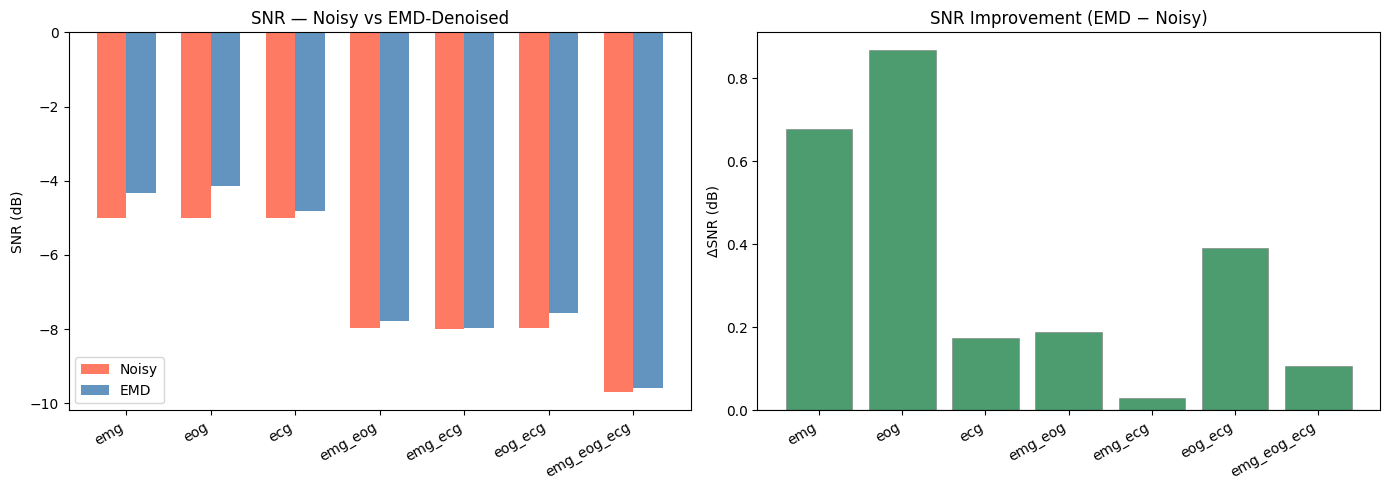

In [30]:
# ── 8a  SNR Comparison Bar Chart ──────────────────────────────────────────────
x = np.arange(len(df))
w = 0.35
labels = df['combo'].tolist()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.bar(x - w/2, df['SNR_dB_noisy'], w, label='Noisy',  color='tomato',    alpha=0.85)
ax.bar(x + w/2, df['SNR_dB_emd'],   w, label='EMD',    color='steelblue', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=30, ha='right')
ax.set_ylabel('SNR (dB)');  ax.set_title('SNR — Noisy vs EMD-Denoised')
ax.legend(); ax.axhline(0, color='black', lw=0.6, ls='--')

ax = axes[1]
colors = ['seagreen' if v >= 0 else 'salmon' for v in df['ΔSNR_dB']]
ax.bar(x, df['ΔSNR_dB'], color=colors, alpha=0.85, edgecolor='grey', lw=0.5)
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=30, ha='right')
ax.set_ylabel('ΔSNR (dB)'); ax.set_title('SNR Improvement (EMD − Noisy)')
ax.axhline(0, color='black', lw=0.8)

plt.tight_layout()
plt.savefig(f'{FIGS_DIR}/snr_comparison.png', dpi=150)
plt.show()

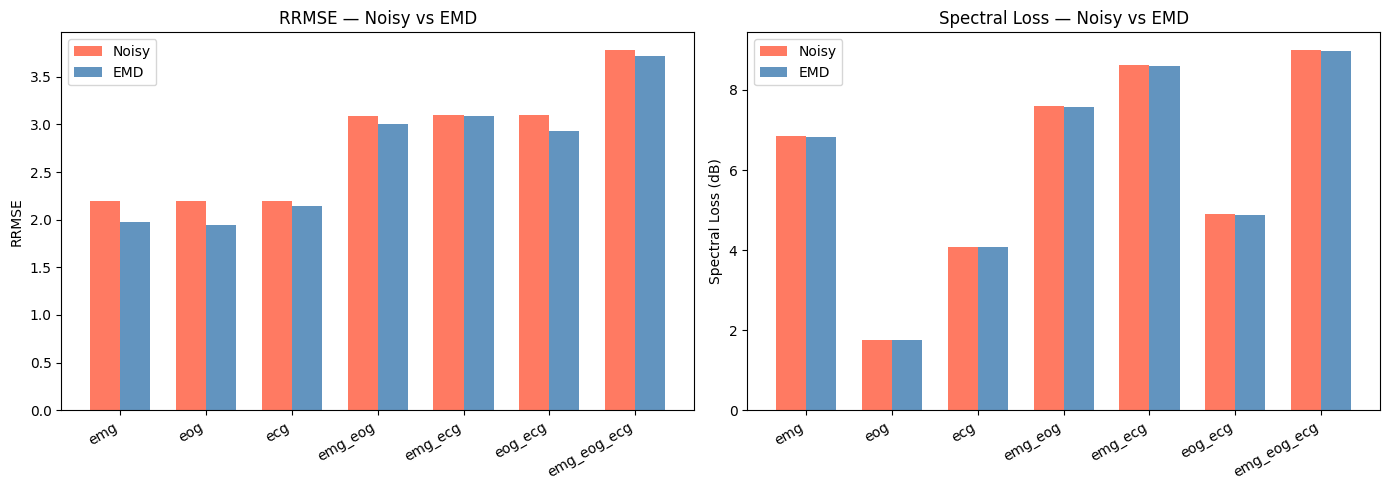

In [31]:
# ── 8b  RRMSE & Spectral Loss ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.bar(x - w/2, df['RRMSE_noisy'], w, label='Noisy', color='tomato',    alpha=0.85)
ax.bar(x + w/2, df['RRMSE_emd'],   w, label='EMD',   color='steelblue', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=30, ha='right')
ax.set_ylabel('RRMSE'); ax.set_title('RRMSE — Noisy vs EMD')
ax.legend()

ax = axes[1]
ax.bar(x - w/2, df['Spectral_Loss_noisy'], w, label='Noisy', color='tomato',    alpha=0.85)
ax.bar(x + w/2, df['Spectral_Loss_emd'],   w, label='EMD',   color='steelblue', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=30, ha='right')
ax.set_ylabel('Spectral Loss (dB)'); ax.set_title('Spectral Loss — Noisy vs EMD')
ax.legend()

plt.tight_layout()
plt.savefig(f'{FIGS_DIR}/rrmse_specloss.png', dpi=150)
plt.show()

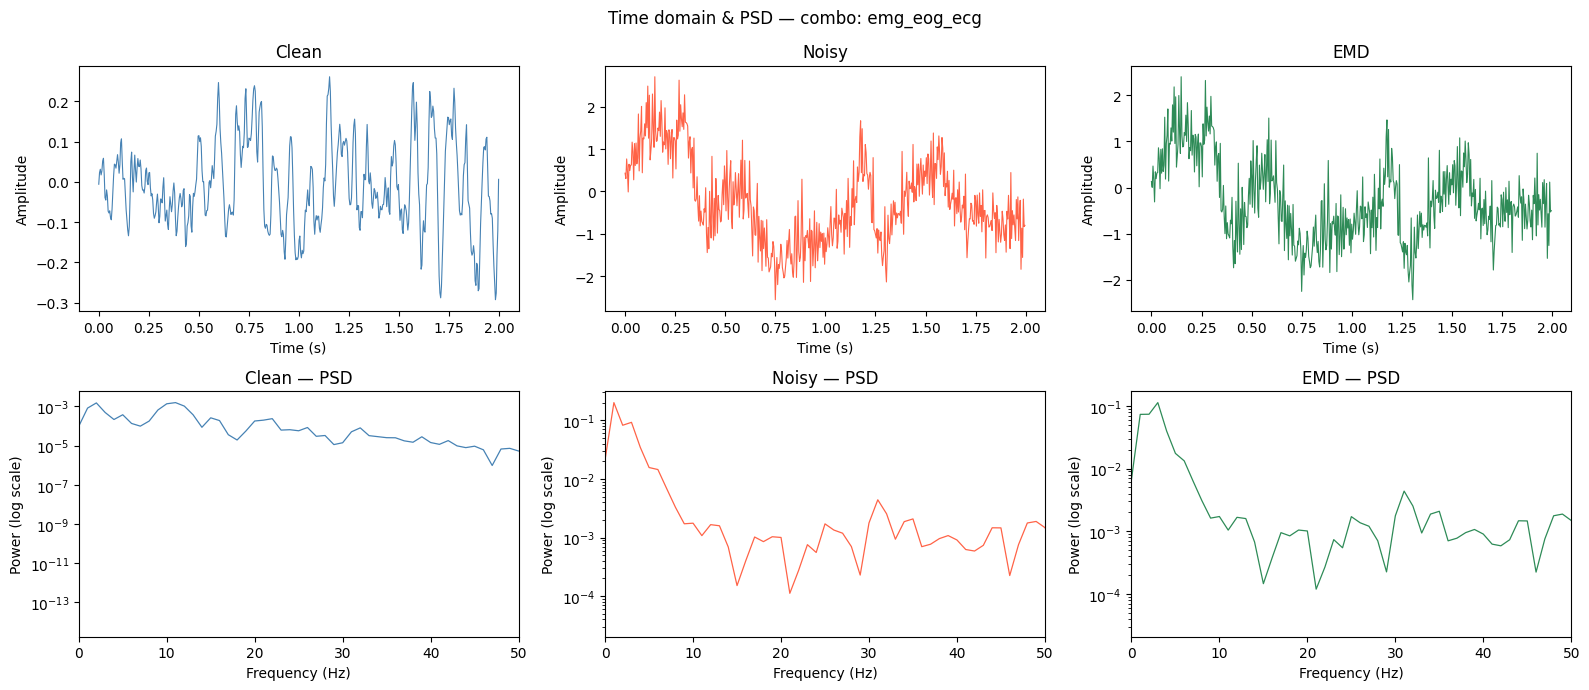

In [32]:
# ── 8c  Time-domain + PSD side-by-side for hardest combo ─────────────────────
combo_plot = 'emg_eog_ecg'
try:
    c_p, n_p = load_h5(combo_plot, 'test', max_samples=3)
    d_p      = emd_denoise_single(n_p[0])
    segs     = [('Clean', c_p[0], 'steelblue'),
                ('Noisy', n_p[0], 'tomato'),
                ('EMD',   d_p,    'seagreen')]

    fig, axes = plt.subplots(2, 3, figsize=(16, 7))
    for col, (lbl, seg, col_c) in enumerate(segs):
        # Time domain
        axes[0, col].plot(t_arr, seg, color=col_c, lw=0.8)
        axes[0, col].set_title(lbl)
        axes[0, col].set_xlabel('Time (s)')
        axes[0, col].set_ylabel('Amplitude')
        # Power spectral density
        f_w, Pw = scipy_signal.welch(seg.astype(np.float64), fs=FS, nperseg=256)
        axes[1, col].semilogy(f_w, Pw, color=col_c, lw=0.9)
        axes[1, col].set_xlim([0, 50])
        axes[1, col].set_title(f'{lbl} — PSD')
        axes[1, col].set_xlabel('Frequency (Hz)')
        axes[1, col].set_ylabel('Power (log scale)')

    fig.suptitle(f'Time domain & PSD — combo: {combo_plot}', fontsize=12)
    plt.tight_layout()
    plt.savefig(f'{FIGS_DIR}/tf_{combo_plot}.png', dpi=150)
    plt.show()
    del c_p, n_p, d_p; gc.collect()
except FileNotFoundError as e:
    print(f'Skipped: {e}')

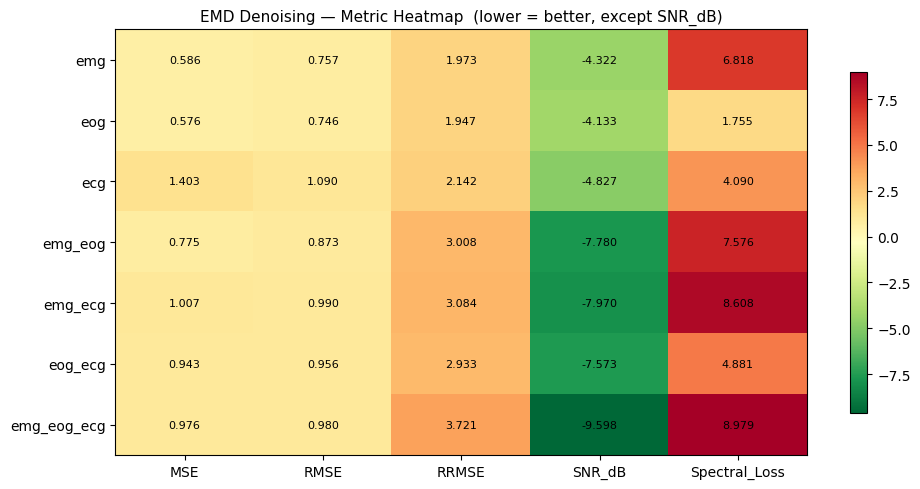

In [33]:
# ── 8d  Metric Heatmap ────────────────────────────────────────────────────────
metric_cols = ['MSE_emd', 'RMSE_emd', 'RRMSE_emd',
               'SNR_dB_emd', 'Spectral_Loss_emd']
hm = df.set_index('combo')[metric_cols]

fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(hm.values, aspect='auto', cmap='RdYlGn_r')
ax.set_xticks(range(len(metric_cols)))
ax.set_xticklabels([c.replace('_emd', '') for c in metric_cols], fontsize=10)
ax.set_yticks(range(len(hm)))
ax.set_yticklabels(hm.index.tolist(), fontsize=10)
for i in range(hm.shape[0]):
    for j in range(hm.shape[1]):
        ax.text(j, i, f'{hm.values[i, j]:.3f}',
                ha='center', va='center', fontsize=8, color='black')
plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_title('EMD Denoising — Metric Heatmap  '
             '(lower = better, except SNR_dB)', fontsize=11)
plt.tight_layout()
plt.savefig(f'{FIGS_DIR}/heatmap.png', dpi=150)
plt.show()

## 9 · Ablation — Energy Threshold Sweep

Threshold sweep:   0%|          | 0/15 [00:00<?, ?thr/s]

  thr=0.10:   0%|          | 0/500 [00:00<?, ?seg/s]

  thr=0.15:   0%|          | 0/500 [00:00<?, ?seg/s]

  thr=0.20:   0%|          | 0/500 [00:00<?, ?seg/s]

  thr=0.25:   0%|          | 0/500 [00:00<?, ?seg/s]

...

  thr=0.65:   0%|          | 0/500 [00:00<?, ?seg/s]

  thr=0.70:   0%|          | 0/500 [00:00<?, ?seg/s]

  thr=0.75:   0%|          | 0/500 [00:00<?, ?seg/s]

  thr=0.80:   0%|          | 0/500 [00:00<?, ?seg/s]


Best threshold  energy_thresh = 0.20  → SNR = -4.243 dB, RRMSE = 1.9994


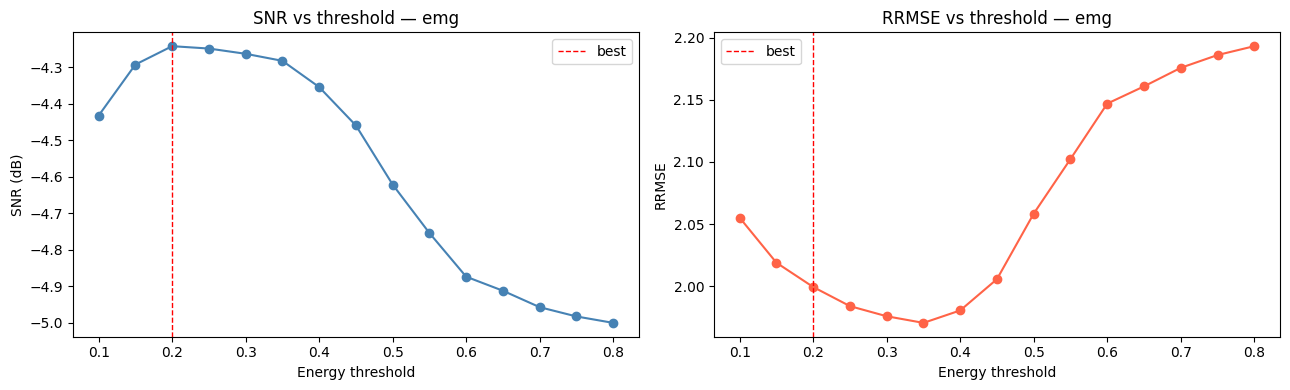

In [34]:
# Sweep energy_thresh on the validation set of one combo to find the optimum.
# Reduce SWEEP_SAMPLES if runtime is too long.
SWEEP_COMBO   = 'emg'
SWEEP_SAMPLES = 500
SWEEP_THRESH  = np.arange(0.10, 0.85, 0.05)

try:
    c_sw, n_sw = load_h5(SWEEP_COMBO, 'val', max_samples=SWEEP_SAMPLES)
    sweep_rows = []

    for thr in tqdm(SWEEP_THRESH, desc='Threshold sweep', unit='thr'):
        d_sw = emd_denoise_batch(
            n_sw, desc=f'  thr={thr:.2f}',
            strategy='energy', energy_thresh=float(thr), mode=THRESHOLD_MODE,
        )
        m = compute_metrics_batch(c_sw, d_sw)
        m['energy_thresh'] = float(thr)
        sweep_rows.append(m)

    df_sw    = pd.DataFrame(sweep_rows)
    best_idx = df_sw['SNR_dB'].idxmax()
    print(f'\nBest threshold  energy_thresh = {df_sw.loc[best_idx, "energy_thresh"]:.2f}  '
          f'→ SNR = {df_sw.loc[best_idx, "SNR_dB"]:.3f} dB, '
          f'RRMSE = {df_sw.loc[best_idx, "RRMSE"]:.4f}')

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(df_sw['energy_thresh'], df_sw['SNR_dB'],  'o-', color='steelblue')
    axes[0].axvline(df_sw.loc[best_idx, 'energy_thresh'],
                    color='red', ls='--', lw=1, label='best')
    axes[0].set_xlabel('Energy threshold'); axes[0].set_ylabel('SNR (dB)')
    axes[0].set_title(f'SNR vs threshold — {SWEEP_COMBO}')
    axes[0].legend()

    axes[1].plot(df_sw['energy_thresh'], df_sw['RRMSE'],   'o-', color='tomato')
    axes[1].axvline(df_sw.loc[best_idx, 'energy_thresh'],
                    color='red', ls='--', lw=1, label='best')
    axes[1].set_xlabel('Energy threshold'); axes[1].set_ylabel('RRMSE')
    axes[1].set_title(f'RRMSE vs threshold — {SWEEP_COMBO}')
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(f'{FIGS_DIR}/threshold_sweep_{SWEEP_COMBO}.png', dpi=150)
    plt.show()

    del c_sw, n_sw, d_sw; gc.collect()
except FileNotFoundError as e:
    print(f'Skipped ablation: {e}')

## 10 · Final Summary

In [35]:
print('=' * 68)
print('  EMD Denoising — Final Results')
print('=' * 68)
print(f'  Strategy      : {IMF_SELECT_STRATEGY}')
print(f'  Threshold mode: {THRESHOLD_MODE}')
if IMF_SELECT_STRATEGY == 'energy':
    print(f'  Energy thresh : {ENERGY_THRESH}')
else:
    print(f'  Artifact IMFs : {N_ARTIFACT_IMFS}')
print(f'  Max IMFs      : {MAX_IMFS}')
print()

summary = df[['combo',
              'MSE_emd', 'RMSE_emd', 'RRMSE_emd',
              'SNR_dB_noisy', 'SNR_dB_emd', 'ΔSNR_dB',
              'Spectral_Loss_emd', 'ΔSpec']].copy()
summary.columns = [
    'Combo', 'MSE', 'RMSE', 'RRMSE',
    'SNR_in', 'SNR_out', 'ΔSNR',
    'SpecLoss', 'ΔSpec'
]
print(summary.to_string(index=False, float_format='{:.4f}'.format))
print()
print(f'  Mean ΔSNR        : {df["ΔSNR_dB"].mean():+.3f} dB')
print(f'  Mean ΔRRMSE      : {df["ΔRRMSE"].mean():+.4f}')
print(f'  Mean ΔSpectral   : {df["ΔSpec"].mean():+.4f} dB')
print()
print(f'  Saved results  → {RESULTS_CSV}')
print(f'  Saved figures  → {FIGS_DIR}/')
print('=' * 68)

  EMD Denoising — Final Results
  Strategy      : energy
  Threshold mode: soft
  Energy thresh : 0.4
  Max IMFs      : 8

      Combo    MSE   RMSE  RRMSE  SNR_in  SNR_out   ΔSNR  SpecLoss   ΔSpec
        emg 0.5857 0.7566 1.9734 -5.0000  -4.3216 0.6784    6.8179  0.0232
        eog 0.5758 0.7463 1.9467 -5.0000  -4.1330 0.8670    1.7555  0.0092
        ecg 1.4033 1.0899 2.1418 -5.0000  -4.8271 0.1729    4.0899 -0.0030
    emg_eog 0.7748 0.8734 3.0082 -7.9679  -7.7795 0.1884    7.5763  0.0149
    emg_ecg 1.0074 0.9898 3.0838 -8.0001  -7.9704 0.0297    8.6076  0.0028
    eog_ecg 0.9429 0.9561 2.9331 -7.9635  -7.5728 0.3907    4.8814  0.0266
emg_eog_ecg 0.9758 0.9801 3.7214 -9.7038  -9.5982 0.1056    8.9790  0.0099

  Mean ΔSNR        : +0.348 dB
  Mean ΔRRMSE      : +0.1192
  Mean ΔSpectral   : +0.0119 dB

  Saved results  → /kaggle/working/emd_results.csv
  Saved figures  → /kaggle/working/figures/


In [36]:
!zip -r emd_results.zip emd_results.csv figures

  adding: emd_results.csv (deflated 48%)
  adding: figures/ (stored 0%)
  adding: figures/snr_comparison.png (deflated 22%)
  adding: figures/threshold_sweep_emg.png (deflated 9%)
  adding: figures/sanity_emg.png (deflated 4%)
  adding: figures/rrmse_specloss.png (deflated 23%)
  adding: figures/imf_decomp_emg.png (deflated 6%)
  adding: figures/heatmap.png (deflated 11%)
  adding: figures/tf_emg_eog_ecg.png (deflated 5%)
